# GPU分布式训练
## 【章节目标】
- 了解 tf.config GPU的使用与分配的方法
- 了解分布式训练理论基础Chapter-10、GPU分布式训练
- 了解tensorflow分布式训练api接口
- 掌握tensorflow分布式训练的方法

## 【章节内容】
### tf.config：GPU的使用与分配
#### 1）指定当前程序使用的GPU
很多时候的场景是：实验室/公司研究组里有许多学生/研究员需要共同使用一台多GPU的工作站，而默 认情况下TensorFlow会使用其所能够使用的所有GPU，这时就需要合理分配显卡资源。

- 获取当前主机特定类型设备列表：tf.config.experimental.list_physical_devices(device_type)
    - device_type：设备类型，如 GPU 或 CPU
- 设置当前程序可见的设备范围：tf.config.experimental.set_visible_devices(devices,device_type)

**代码示例**

In [2]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices(device_type = 'GPU')
cpus = tf.config.experimental.list_physical_devices(device_type = 'CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


注意：只有当主机带有GPU设备，并且安装了适配的 CUDA 和 驱动后才能正常输出GPU设置

In [ ]:
#要限定当前程序只使用下标为0、1的两块显卡（ GPU:0 和 GPU:1 ）  我只有一块显卡运行不了
tf.config.experimental.set_visible_devices(devices=gpus[0:2], device_type='GPU')

使用环境变量 CUDA_VISIBLE_DEVICES 也可以控制程序所使用的GPU。假设发现四卡的机器上显卡0,1 使用中，显卡2,3空闲，Linux终端输入:

export CUDA_VISIBLE_DEVICES=2,3

或在python代码中加入:

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "2, 3"

#### 2）设置显存使用策略
默认情况下，TensorFlow将使用几乎所有可用的显存，以避免内存碎片化所带来的性能损失。不过， TensorFlow提供两种显存使用策略，让我们能够更灵活地控制程序的显存使用方式：

- tf.config.experimental.set_memory_growth:仅在需要时申请显存空间（程序初始运行时消耗很少的显存，随着程序的运行而动态申请显存）；

- tf.config.experimental.set_virtual_device_configuration 限制消耗固定大小的显存（程序不会超出限定的显存大小，若超出的报错）。

**将所有GPU设置为仅在需要时申请显存空间，这里在启动container的时候配置了**

In [ ]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(device=gpu, enable=True)

通过 tf.config.experimental.set_virtual_device_configuration 选项并传入tf.config.experimental.VirtualDeviceConfiguration 实例，设置TensorFlow固定消耗 GPU:0 的1GB 显存（其实可以理解为建立了一个显存大小为1GB的“虚拟GPU”）

In [ ]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
tf.config.experimental.set_virtual_device_configuration(
    gpus[0],
    [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024)]
)

#### 3）单GPU模拟多GPU环境

当我们的本地开发环境只有一个GPU，但却需要编写多GPU的程序在工作站上进行训练任务时， TensorFlow为我们提供了一个方便的功能，可以让我们在本地开发环境中建立多个模拟GPU，从而让 多GPU的程序调试变得更加方便。

**以下代码在实体 GPU:0 的基础上建立了两个显存均为2GB的虚拟GPU。**

In [3]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
tf.config.experimental.set_virtual_device_configuration(
    gpus[0],
    [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2048),
     tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2048)]
)

In [4]:
tf.config.experimental.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
tf.config.experimental.list_logical_devices('GPU')

2026-04-08 14:23:53.929625: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2026-04-08 14:23:53.930665: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


[LogicalDevice(name='/device:GPU:0', device_type='GPU'),
 LogicalDevice(name='/device:GPU:1', device_type='GPU')]

#### 4）GPU实战tfflowers
前面章节都是在gpu训练，tensorflow不需要像pytorch那样指定，默认就在cpu上
1、构建数据集...

### 分布式训练理论简介
#### 1）分布式训练简介
总的来说，分布式训练分为这几类：

- 按照并行方式来分：模型并行 vs 数据并行
- 按照更新方式来分：同步更新 vs 异步更新
- 按照算法来分：Parameter Server算法 vs AllReduce算法

#### 2）模型并行 vs 数据并行
假设我们有n张GPU：
- 模型并行：不同的GPU输入相同的数据，运行模型的不同部分，比如多层网络的不同层；
- 数据并行：不同的GPU输入不同的数据，运行相同的完整的模型

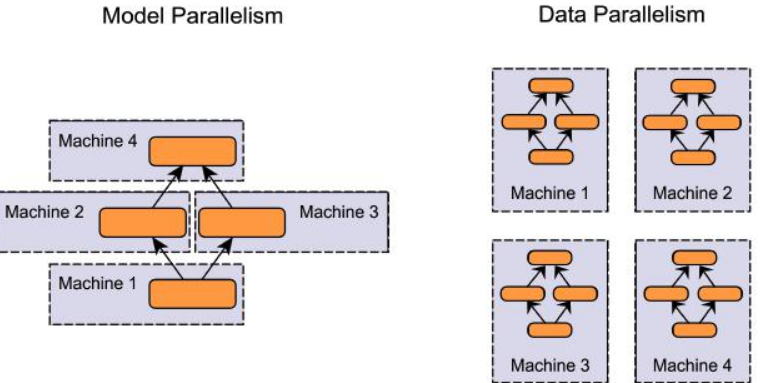

当模型非常大，一张GPU已经存不下的时候，可以使用模型并行，把模型的不同部分 交给不同的机器负责，但是这样会带来很大的通信开销，而且模型并行各个部分存在一定的依赖，规模伸缩性差。

因此，通常一张可以放下一个模型的时候，会采用数据并行的方式，各部分独立，伸缩性好。

#### 3）同步更新 vs 异步更新
对于数据并行来说，由于每个GPU负责一部分数据，那就涉及到如果更新参数的问题，分为同步更新和异步更新两种方式。

- 同步更新：每个batch所有GPU计算完成后，再统一计算新权值，然后所有 GPU 同步新值后，再进行下一轮计算。
- 异步更新：每个GPU计算完梯度后，无需等待其他更新，立即更新整体权值并同步。

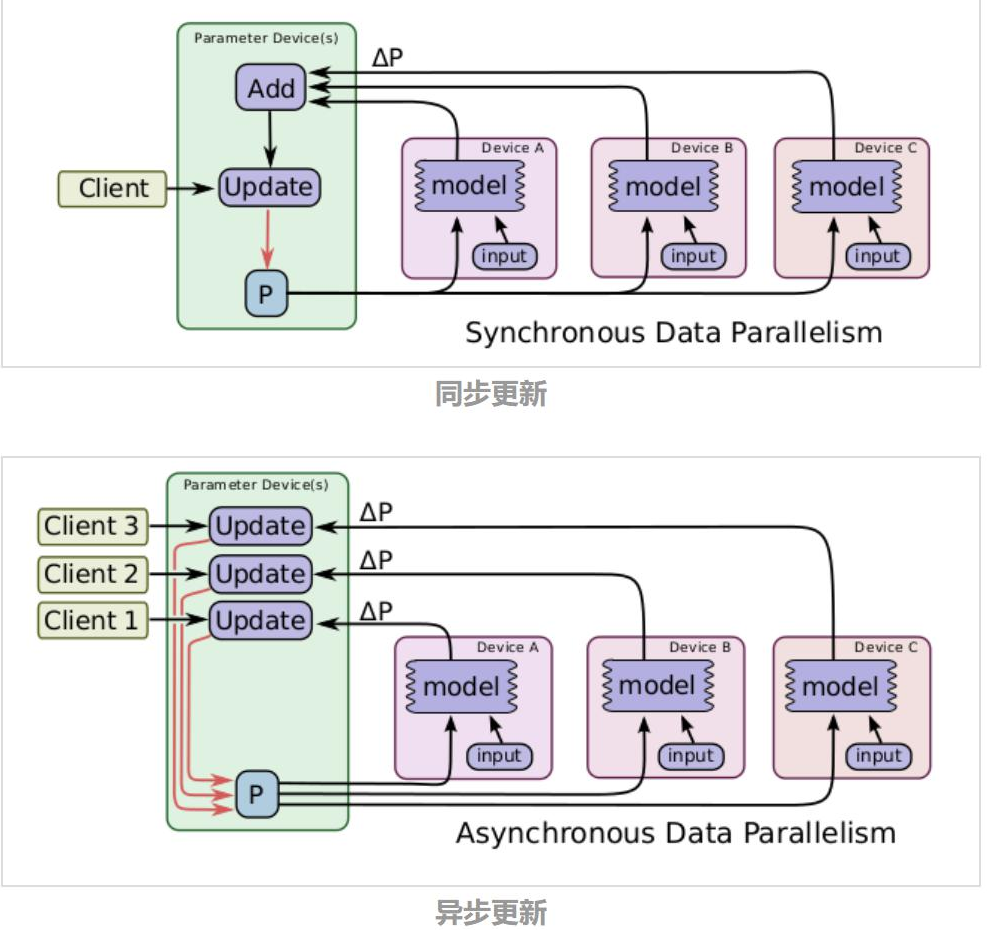

- 二者区别：同步更新有等待，速度取决于最慢的那个GPU；异步更新没有等待，但是会出现loss异常抖动等问题。所以实践中，一般使用同步更新的方式

#### 4）Parameter Server算法 vs Ring AllReduce算法
常用的两种参数同步的算法：PS 和 Ring AllReduce。

- Parameter Server：GPU 0将数据分成五份分到各个卡上，每张卡负责自己的那一 份mini-batch的训练，得到grad后，返回给GPU 0上做累积，得到更新的权重参数 后，再分发给各个卡。

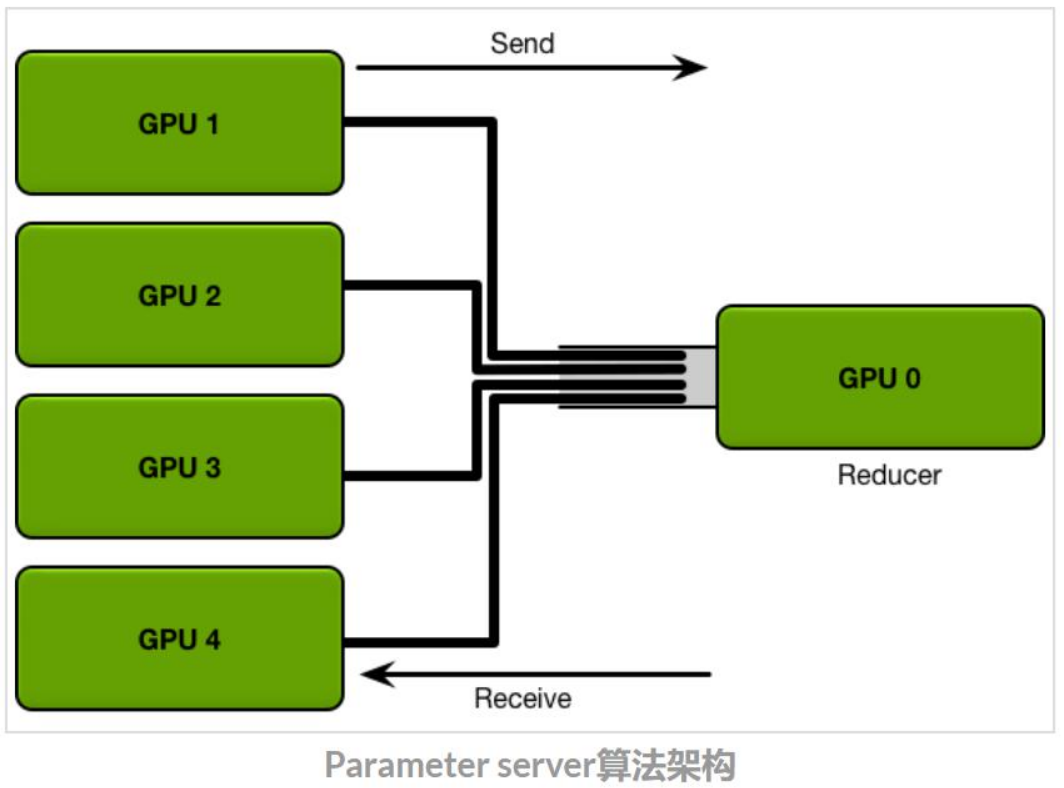

- Ring AllReduce：5张以环形相连，每张卡都有左手卡和右手卡，一个负责接收， 一个负责发送，循环4次完成梯度累积，再循环4次做参数同步。分为Scatter Reduce和All Gather两个环节

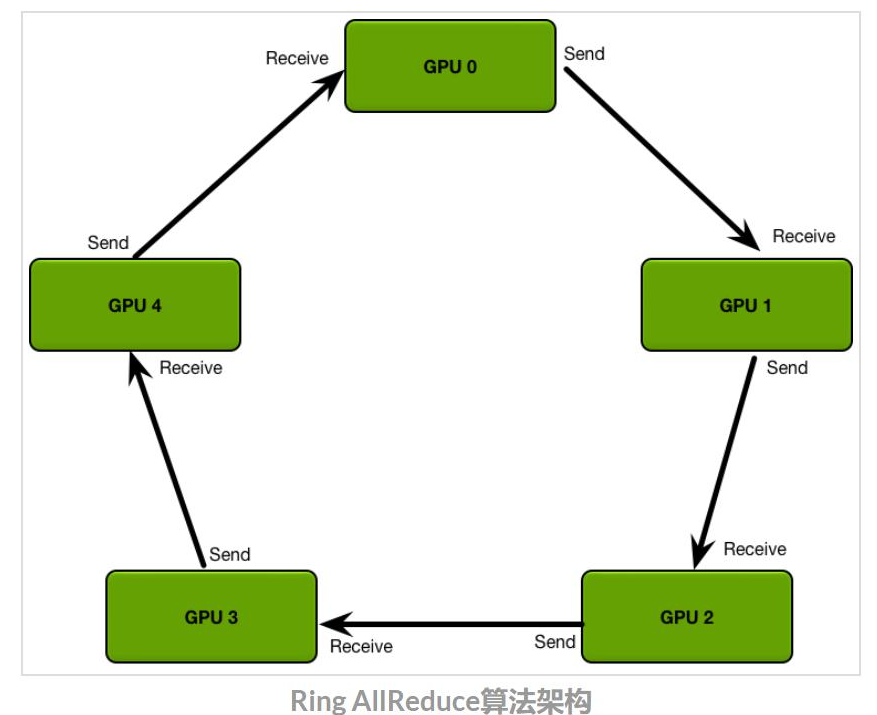

### 分布式训练API接口
#### 1）tf.distribute.Strategy简介
tf.distribute.Strategy是TensorFlow API，用于在多个GPU，多台机器或TPU之间分布式训练。使用此API，你可以在更改最少的代码情况下分发现有模型和训练代码。

tf.distribute.Strategy 设计时考虑了以下主要目标：

- 易于使用并支持多个用户细分，包括研究人员，ML工程师等。
- 开箱即用地提供良好的性能。
- 轻松切换策略。

tf.distribute.Strategy可以与Keras之类的高级API一起使用，也可以用于分发自定义训练模型（以及通常使用TensorFlow进行的任何计算）。

**六种分布式策略：**

- tf.distribute.Strategy
- tf.distribute.MirroredStrategy
- tf.distribute.TPUStrategy
- tf.distribute.MultiWorkerMirroredStrategy
- tf.distribute.CentralStorageStrategy
- tf.distribute.ParameterServerStrategy

tf.distribute.Strategy 计划覆盖多种使用场景。一些组合已经支持，一些会在未来添加。

- 同步和异步训练（Synchronous vs asynchronous training）：这是两种常见分布式训练方法。在同步（sync）训练中，所有wokers同步训练输入数据的不同分片，在每个step中汇总梯度。在异步（async）训练中，所有worker独立训练输入数据以及异步更新变量。一般地，同步训练通过all-reduce来支持，异步训练通过ps架构来支持。
- 硬件平台：在一个网络中，你可能想在一个或多个机器上或云TPU上，通过多GPU来扩展训练。

#### 2）MirroredStrategy
tf.distribute.MirroredStrategy支持在一台机器上在多个GPU上进行同步分布式训练。 每个GPU设备创建一个副本。模型中的每个变量都将在所有副本之间进行保存。这些变量共同构成一个称为的概念变量 MirroredVariable。通过应用相同的更新，这些变量彼 此保持同步。

设备上的变量更新使用高效的all-reduce算法。All-reduce通过加法对所有设备上的张量进行融合，使其在每个设备上可用。这种安全的算法，可以显著减少同步的开销。有很多种方法可以实现all-reduce算法，不同算法的区别在于设备上变量之间的通信方法不同。默认使用NVIDIA NCCL作为all-reduce实现。你也可以使用我们提供的其他选项，或者自己实现。

**创建MirroredStrategy的最简单方法(这会创建一个MirroredStrategy实例，这个实例会使用对TensorFlow可见的所有GPU，以及使用NCCL作为设备通信的方式。):**

In [6]:
import tensorflow as tf
mirrored_strategy = tf.distribute.MirroredStrategy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


**如果你想只使用机器上的部分GPU，你可以这么做：**

In [7]:
mirrored_strategy = tf.distribute.MirroredStrategy(devices=["/gpu:0", "/gpu:1"])

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


**示例代码**

In [8]:
strategy = tf.distribute.MirroredStrategy(["GPU:0", "GPU:1"])
with strategy.scope():
    x = tf.Variable(1.)
x

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


MirroredVariable:{
  0: <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.0>,
  1: <tf.Variable 'Variable/replica_1:0' shape=() dtype=float32, numpy=1.0>
}

#### 3）CentralStorageStrategy
tf.distribute.experimental.CentralStorageStrategy 也是同步训练方式。但是变量不再是镜像变量，变量被放置在CPU中，而在本地GPU中进行计算。如果只有一个GPU，那么所有变量和计算都在GPU上。

**创建一个CentralStorageStrategy实例：**

In [9]:
central_storage_strategy = tf.distribute.experimental.CentralStorageStrategy()

INFO:tensorflow:ParameterServerStrategy (CentralStorageStrategy if you are using a single machine) with compute_devices = ['/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1'], variable_device = '/device:CPU:0'


以上代码会创建一个使用所有可见GPU和CPU的CentralStorageStrategy实例。在GPU副本上的参数更新之前，所有变量会先进行聚合。（即，分散在local的GPU上的变量先aggregated到CPU，然后在从CPU应用到各个GPU上）

#### 4）MultiWorkerMirroredStrategy
tf.distribute.experimental.MultiWorkerMirroredStrategy与MirroredStrategy非常相似。它实现了跨多个工作机器的同步分布式训练，每个工作机器可能具有多个GPU。与 MirroredStrategy相似，它会在所有工作机器的每台设备上的模型中创建所有变量的副本。

它使用CollectiveOps作为多机器all-reduce通信方法，用于使变量保持同步。集合运算是TensorFlow图中的单个运算，它可以根据硬件，网络拓扑和张量大小在TensorFlow 运行时中自动选择all-reduce算法。

**创建一个MultiWorkerMirroredStrategy实例的最简单方法：**

In [10]:
multiworker_strategy = tf.distribute.experimental.MultiWorkerMirroredStrategy()

Instructions for updating:
use distribute.MultiWorkerMirroredStrategy instead
INFO:tensorflow:Using MirroredStrategy with devices ('/device:GPU:0', '/device:GPU:1')
INFO:tensorflow:Single-worker MultiWorkerMirroredStrategy with local_devices = ('/device:GPU:0', '/device:GPU:1'), communication = CommunicationImplementation.AUTO


MultiWorkerMirroredStrategy 目前允许你选择两种不同的集合操作实现:

- CollectiveCommunication.RING 使用gRPC作为通信层，实现了ring-based collectives。
- CollectiveCommunication.NCCL 使用 Nvidia's NCCL，实现了collectives。
- CollectiveCommunication.AUTO 为运行定义了选择。

最好的集合实现的选择取决于GPUs的数量和种类，以及集群中的网络连接。你可以通过下面的方法进行指定

In [ ]:
multiworker_strategy = tf.distribute.experimental\
                        .MultiWorkerMirroredStrategy(tf.distribute.experimental.CollectiveCommunication.NCCL)

#### 5）ParameterServerStrategy
tf.distribute.experimental.ParameterServerStrategy支持多台机器上的参数服务器训练。在这个配置里面，一些机器被分配为workers，一些被分配为参数服务器。模型的每个参数都放在一个参数服务器上。计算被复制在所有机器的GPUs上。

**就代码而言，这个策略和其他策略是相似的：**

In [ ]:
ps_strategy = tf.distribute.experimental.ParameterServerStrategy()

注意：ParameterServerStrategy 该分布式训练方式需结合其他多个参数使用，因此以上代码仅供参考，无需运行

### 分布式训练方法
#### 1）Keras方式分布式训练
tf已经把 tf.distribute.Strategy 整合到 tf.Keras，tf.Keras 是 Keras API specification 的TensorFlow实现。tf.Keras是构建和训练模型的高级接口。通过整合到 tf.Keras 后台，分布式训练可以无缝写在 Keras 训练构建中。

**代码中需要改动的地方：**

- 1、创建一个适当的 tf.distribute.Strategy 实例。
- 2、将Keras模型，优化器和指标的创建移到strategy.scope内部。

支持所有类型的Keras模型- sequential, functional and subclassed。

In [11]:
import numpy as np
# 1. Create an instance of the appropriate tf.distribute.Strategy
mirrored_strategy = tf.distribute.MirroredStrategy()
# 2.  Move the creation and compiling of Keras model inside strategy.scope.
with mirrored_strategy.scope():
    model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape = (1,))]) # 搭建模型代码
    model.compile(loss = 'mse', optimizer = 'sgd') # 模型compile配置代码 损失 优化器 指标
dataset = tf.data.Dataset.from_tensors(([1.], [1.])).repeat(100).batch(10)
model.fit(dataset, epochs=2)
model.evaluate(dataset)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Epoch 1/2
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:local

I0000 00:00:1775661328.587314   29767 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 2/2
10/10 [==============================] - ETA: 0s - loss: 1.7952INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
10/10 [==============================] - 1s 9ms/step - loss: 1.1149


1.1148689985275269

#### 2）自定义方式分布式训练
为了支持自定义训练循环，我们通过 tf.distribute.Strategy 类提供了一系列方法。使用这些方法需要重构少量代码初始化，但是一旦完成，你需要通过简单修改策略实例来在GPUs、TPUs和多机之间切换。

**1.首先，在策略空间中，创建模型和优化器。确保在模型和优化器中的变量都是镜像变量。**

In [12]:
mirrored_strategy = tf.distribute.MirroredStrategy()
with mirrored_strategy.scope():
    model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape = (1,))])
    optimizer = tf.keras.optimizers.SGD()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


**2.下一步，创建dataset输入，并调用 tf.distribute.Strategy.experimental_distribute_dataset 基于这个策略分发dataset。**

In [13]:
global_batch_size = 32
dataset = tf.data.Dataset.from_tensors(([1.], [1.])).repeat(1000).batch(global_batch_size)
dist_dataset = mirrored_strategy.experimental_distribute_dataset(dataset) # 封装成分布式数据集

**3.然后，定义训练的step。我们会使用 tf.GradientTape 来计算梯度，使用优化器来更新模型的变量。为了分布式训练的step，我们put in一个 step_fn 函数，把它和刚刚创建的 dist_dataset 传到 tf.distribute.Strategy.run 里。**

In [14]:
@tf.function
def train_step(dist_inputs):
    def step_fn(inputs):
        features, labels = inputs
        with tf.GradientTape() as tape:
            # training=True is only needed if there are layers with different
            # behavior during training versus inference (e.g. Dropout).
            logits = model(features, training=True) #前向传播
            cross_entropy = tf.nn.softmax_cross_entropy_with_logits(logits = logits, labels = labels) # 计算损失
            loss = tf.reduce_sum(cross_entropy) * (1.0 / global_batch_size) # 计算平均损失

            grads = tape.gradient(loss, model.trainable_variables) # 求梯度
            optimizer.apply_gradients(list(zip(grads, model.trainable_variables))) # 更新参数
        return cross_entropy
    
    per_example_loss = mirrored_strategy.run(step_fn, args=(dist_inputs,))
    mean_loss = mirrored_strategy.reduce(
        tf.distribute.ReduceOp.MEAN, per_example_loss, axis = 0
    ) # 所有设备的损失求平均
    return mean_loss

代码中需要注意的地方：

- 1、使用 tf.nn.softmax_cross_entropy_with_logits 计算loss。并通过 global_batch_size来调整loss。这是非常重要的，因为所有副本在同步训练，每一步训练的样本是全局的batch。因此，loss需要除以全局的batch大小，而不是本地副本（replica）的batch大小。
- 2、使用 tf.distribute.Strategy.reduce API 来聚合 tf.distribute.Strategy.run返回的结果。tf.distribute.Strategy.run 返回的是策略中本地副本（replica）的结果，有多种方法可以消费这些结果。可以通过 reduce 他们来聚合值。也可以通过 tf.distribute.Strategy.experimental_local_results 来获得本地副本结果中的多个值。
- 3、当 apply_gradients 在分布式策略命名空间中被调用时，它的行为会被修改。尤其是在同步训期间，并行实例更新梯度之前，它运行梯度的一个所有副本的和。

**4.最终，当我们定义好训练地step之后，我们可以在 dist_dataset 上迭代并在训练中训练：**

In [15]:
with mirrored_strategy.scope():
    for inputs in dist_dataset: # 遍历数据
        print(train_step(inputs)) # 进行训练

INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)


### 分布式训练实战tf_flowers
#### 1）Keras方式分布式训练模型

**虚拟2个gpu**

In [1]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU') 
tf.config.experimental.set_virtual_device_configuration( 
    gpus[0], 
    [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=3072), 
     tf.config.experimental.VirtualDeviceConfiguration(memory_limit=3072)])

2026-04-08 15:42:29.200156: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 15:42:29.200360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 15:42:29.205944: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
tf.config.experimental.list_logical_devices('GPU')

2026-04-08 15:43:05.685046: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2026-04-08 15:43:05.685783: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


[LogicalDevice(name='/device:GPU:0', device_type='GPU'),
 LogicalDevice(name='/device:GPU:1', device_type='GPU')]

**构建数据集**

In [3]:
import tensorflow as tf
import random
import pathlib
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))  
all_image_paths = [str(path) for path in all_image_paths]  # 所有图片路径的列表
random.shuffle(all_image_paths)  # 打散
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir()) #加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names)) #构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths] #标签id化

#分割数据集
total_num=len(all_image_paths)
split_index=int(0.8 * total_num)
train_x,train_y=all_image_paths[:split_index],all_image_labels[:split_index]
val_x,val_y=all_image_paths[split_index:],all_image_labels[split_index:]

AUTOTUNE = tf.data.AUTOTUNE

#构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x, train_y))
val_db= tf.data.Dataset.from_tensor_slices((val_x, val_y))

#定义预处理方法
def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path)  # 读取图片
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [192, 192])  # 原始图片大小为(266, 320, 3)，重设为(192, 192)
    image /= 255.0  # 归一化到[0,1]范围
    return image, label
train_db = train_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)
val_db = val_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)

#打乱并分批次
# 这里的 64 是 Global Batch Size，每个虚拟 GPU 会分到 32
GLOBAL_BATCH_SIZE = 64 
train_db = train_db.cache().shuffle(1000).batch(GLOBAL_BATCH_SIZE).prefetch(AUTOTUNE)
val_db = val_db.cache().batch(GLOBAL_BATCH_SIZE).prefetch(AUTOTUNE)

**定义Strategy并搭建模型**

In [4]:
mirrored_strategy = tf.distribute.MirroredStrategy()
with mirrored_strategy.scope(): #模型/优化器
    num_classes = len(label_names)
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes)
    ]) 
    model.build(input_shape = (None, 192, 192, 3)) # 初始化模型参数
    model.summary()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer = optimizer,
                  loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics = ['accuracy'])

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 190, 190, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 95, 95, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 93, 93, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 46, 46, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 44,

In [5]:
model.fit(train_db, epochs=10, validation_data=val_db)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/r

I0000 00:00:1775664053.993899   60348 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 [==============================] - ETA: 0s - loss: 1.4695 - accuracy: 0.3542INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
46/46 [==============================] - 18s 154ms/step - loss: 1.4695 - accuracy: 0.3542 - val_loss: 1.3413 - val_accuracy: 0.4237
Epoch 2/10
46/46 [==============================] - 3s 66ms/step - loss: 1.2258 - accuracy: 0.4745 - val_loss: 1.1751 - val_accuracy: 0.4959
Epoch 3/10
46/46 [==============================] - 3s 68ms/step - loss: 1.0966 - accuracy: 0.5487 - val_loss: 1.0657 - val_accuracy: 0.5599
Epoch 4/10
46/46 [==============================] - 3s 66ms/step - loss: 1.0263 - accuracy: 0.5913 - val_loss: 1.0205 - val_accuracy: 0.5817
Epoch 5/10
46/46 [==============================] - 3s 68ms/step - loss: 0.9687 - a

#### 2）自定义方式分布式训练模型
***这里也完善了一下前面用到的代码（Loss 的计算与汇总部分，最好修正成下面这种写法）***

**虚拟2个gpu**

In [1]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU') 
tf.config.experimental.set_virtual_device_configuration( 
    gpus[0], 
    [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=3072), 
     tf.config.experimental.VirtualDeviceConfiguration(memory_limit=3072)])

2026-04-08 16:23:29.350880: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 16:23:29.350944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 16:23:29.352001: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**构建模型**

In [2]:
mirrored_strategy = tf.distribute.MirroredStrategy()
with mirrored_strategy.scope():
    num_classes=5
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes)
    ])
    model.build(input_shape=(None, 192,192,3))#初始化模型参数
    model.summary()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    # Metric 在 Strategy 作用域内创建，它会自动聚合各 GPU 的数据
    acc = tf.keras.metrics.SparseCategoricalAccuracy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 190, 190, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 95, 95, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 93, 93, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 46, 46, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 44,

2026-04-08 16:32:50.479552: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2026-04-08 16:32:50.480341: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


**构建数据集**

In [3]:
import random
import pathlib
data_path = pathlib.Path('Dataset/flower_photos/')
all_image_paths = list(data_path.glob('*/*'))  
all_image_paths = [str(path) for path in all_image_paths]  # 所有图片路径的列表
random.shuffle(all_image_paths)  # 打散
label_names = sorted(item.name for item in data_path.glob('*/') if item.is_dir())#加载标签
label_to_index = dict((name, index) for index, name in enumerate(label_names))#构建标签字典
all_image_labels = [label_to_index[pathlib.Path(path).parent.name] for path in all_image_paths]#标签id化

#分割数据集
total_num=len(all_image_paths)
split_index=int(0.8*total_num)
train_x,train_y=all_image_paths[:split_index],all_image_labels[:split_index]
val_x,val_y=all_image_paths[split_index:],all_image_labels[split_index:]

#构建数据集
train_db = tf.data.Dataset.from_tensor_slices((train_x,train_y))
val_db= tf.data.Dataset.from_tensor_slices((val_x,val_y))

AUTOTUNE = tf.data.AUTOTUNE

#定义预处理方法
def load_and_preprocess_from_path_label(path, label):
    image = tf.io.read_file(path)  # 读取图片
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.cast(image, tf.float32) # 类型转换确保一下
    image = tf.image.resize(image, [192, 192])  # 原始图片大小为(266, 320, 3)，重设为(192, 192)
    image /= 255.0  # 归一化到[0,1]范围
    return image, label

train_db = train_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)
val_db = val_db.map(load_and_preprocess_from_path_label, num_parallel_calls=AUTOTUNE)


#打乱并分批次
global_batch_size=32

train_db = train_db.cache().shuffle(1000).batch(global_batch_size).prefetch(AUTOTUNE)
val_db = val_db.cache().batch(global_batch_size).prefetch(AUTOTUNE)

train_db_len = len(train_db)
val_db_len = len(val_db)
# 将数据集包装为分布式数据集
dist_train_db = mirrored_strategy.experimental_distribute_dataset(train_db)
dist_val_db = mirrored_strategy.experimental_distribute_dataset(val_db)

**编写迭代函数并进行训练**

In [4]:
@tf.function
def train_step(dist_inputs):
    def step_fn(inputs):
        features, labels = inputs

        with tf.GradientTape() as tape:
          # training=True is only needed if there are layers with different
          # behavior during training versus inference (e.g. Dropout).
            logits = model(features, training=True)
            # 计算无均值的交叉熵张量
            cross_entropy = tf.nn.sparse_softmax_cross_entropy_with_logits(logits=logits, labels=labels)
            # 用总数除以 global_batch_size 得到标量 Loss
            loss = tf.reduce_sum(cross_entropy) * (1.0 / global_batch_size)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(list(zip(grads, model.trainable_variables)))
        acc.update_state(labels, logits)
        return loss
    # 运行各个副本，并使用 SUM 聚合每个副本计算出的部分 Loss
    per_replica_losses= mirrored_strategy.run(step_fn, args=(dist_inputs,))
    mean_loss = mirrored_strategy.reduce(
        tf.distribute.ReduceOp.SUM, per_replica_losses, axis=None)
    return mean_loss


@tf.function
def test_step(dist_inputs):
    def step_fn(inputs):
        features, labels = inputs
        logits = model(features, training=False)
        cross_entropy = tf.nn.sparse_softmax_cross_entropy_with_logits(logits=logits, labels=labels)
        loss = tf.reduce_sum(cross_entropy) * (1.0 / global_batch_size)
        acc.update_state(labels, logits)
        return loss
    #运行出每个副本上的数据
    per_replica_loss= mirrored_strategy.run(step_fn, args=(dist_inputs,))
    #将所有副本数据秋平均
    mean_loss = mirrored_strategy.reduce(
        tf.distribute.ReduceOp.SUM, per_replica_loss, axis=None)
    return mean_loss

epochs=10
#训练  遍历epochs 
for epoch in range(1,epochs+1):
    print('-'*10+f"epoch{epoch}"+'-'*10)

    #Training
    train_loss=0
    acc.reset_states()
    #with mirrored_strategy.scope(): # 训练循环不需要scope()
    # 当进入 for epoch 循环时，所有的变量早就创建完毕了。
    # 而且 train_step 函数内部已经明确使用了 mirrored_strategy.run(step_fn, ...)
    # 这个 .run() 方法本身就自带了分布式执行的上下文。
    for step,inputs in enumerate(dist_train_db):
        loss=train_step(inputs)
        train_loss += loss.numpy() / train_db_len#累计平均损失

        if step % 10 == 0:
            print('Training at step %s,loss: %s,acc:%s' % (step,
                                                            loss.numpy(),
                                                            acc.result().numpy()))
    print('epoch %s---Training loss : %s---Training acc : %s ' % (epoch, 
                                                                      float(train_loss),
                                                                      acc.result().numpy()))
    #遍历验证机进行验证
    val_loss=0
    acc.reset_states()
    #with mirrored_strategy.scope():
    for inputs in dist_val_db:
        loss=test_step(inputs)
        val_loss += loss.numpy() / val_db_len#累计平均损失
    print('epoch %s---val loss : %s---val acc : %s ' % (epoch, 
                                                        float(val_loss),
                                                        acc.result().numpy()))
    

----------epoch1----------
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.RING, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


I0000 00:00:1775667306.479059   80633 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Training at step 0,loss: 1.6153574,acc:0.15625
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Training at step 10,loss: 1.5431268,acc:0.29545453
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Training at step 20,loss: 1.510423,acc:0.33630952
Training at 